# Noise Worksheet: Heteroscedastic vs Homoscedastic Noise
## Gen 575 – Fundamentals of Biomedical Instrumentation

In this worksheet you'll explore two fundamental types of measurement noise:

- **Homoscedastic noise** (signal-independent): The variance of the noise is constant regardless of the signal level. Example: Johnson (thermal) noise in electronics.
- **Heteroscedastic noise** (signal-dependent): The variance of the noise scales with the signal level. Example: Shot (Poisson) noise from counting discrete events (ions, photons).

Real instruments always have both present simultaneously. Understanding which dominates — and when — is critical for experimental design.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats

np.random.seed(575)  # For reproducibility

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 13
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

## Part 1: Generating Noisy Data

The cell below simulates measurements from a hypothetical detector that has **both** types of noise. We'll measure a series of samples at different true signal levels.

- **Homoscedastic component (Johnson noise):** σ_thermal = constant, independent of signal
- **Heteroscedastic component (shot noise):** σ_shot = √(signal), since shot noise variance equals the signal for Poisson processes

In [2]:
# Simulated detector with both noise sources
sigma_thermal = 5.0   # constant thermal noise (in arbitrary detector units)

# True signal levels spanning 3 orders of magnitude (like varying analyte concentration)
true_signals = np.array([10, 25, 50, 100, 250, 500, 1000, 2500, 5000, 10000])

n_replicates = 50  # measurements per signal level

# Generate measurements
all_data = []
for true_signal in true_signals:
    # Shot noise: standard deviation = sqrt(signal) for Poisson counting
    sigma_shot = np.sqrt(true_signal)
    
    # Total noise is the sum of both (variances add)
    total_sigma = np.sqrt(sigma_thermal**2 + sigma_shot**2)
    
    # Simulate measurements
    measurements = np.random.normal(true_signal, total_sigma, n_replicates)
    
    for m in measurements:
        all_data.append({
            'true_signal': true_signal,
            'measurement': m,
            'sigma_thermal': sigma_thermal,
            'sigma_shot': sigma_shot,
            'sigma_total': total_sigma
        })

df = pd.DataFrame(all_data)
print(f"Generated {len(df)} measurements across {len(true_signals)} signal levels")
print(f"\nFirst few rows:")
df.head(10)

Generated 500 measurements across 10 signal levels

First few rows:


,true_signal,measurement,sigma_thermal,sigma_shot,sigma_total
0,10,2.113413,5.0,3.162278,5.91608
1,10,15.330508,5.0,3.162278,5.91608
2,10,19.561024,5.0,3.162278,5.91608
3,10,9.210154,5.0,3.162278,5.91608
4,10,-3.269502,5.0,3.162278,5.91608
5,10,6.443942,5.0,3.162278,5.91608
6,10,5.436475,5.0,3.162278,5.91608
7,10,19.209840,5.0,3.162278,5.91608
8,10,10.707963,5.0,3.162278,5.91608
9,10,16.211661,5.0,3.162278,5.91608


## Part 2: Visualize the Raw Data

**Exercise 1:** Run the cell below to plot all measurements vs true signal. Look at how the scatter changes across signal levels.

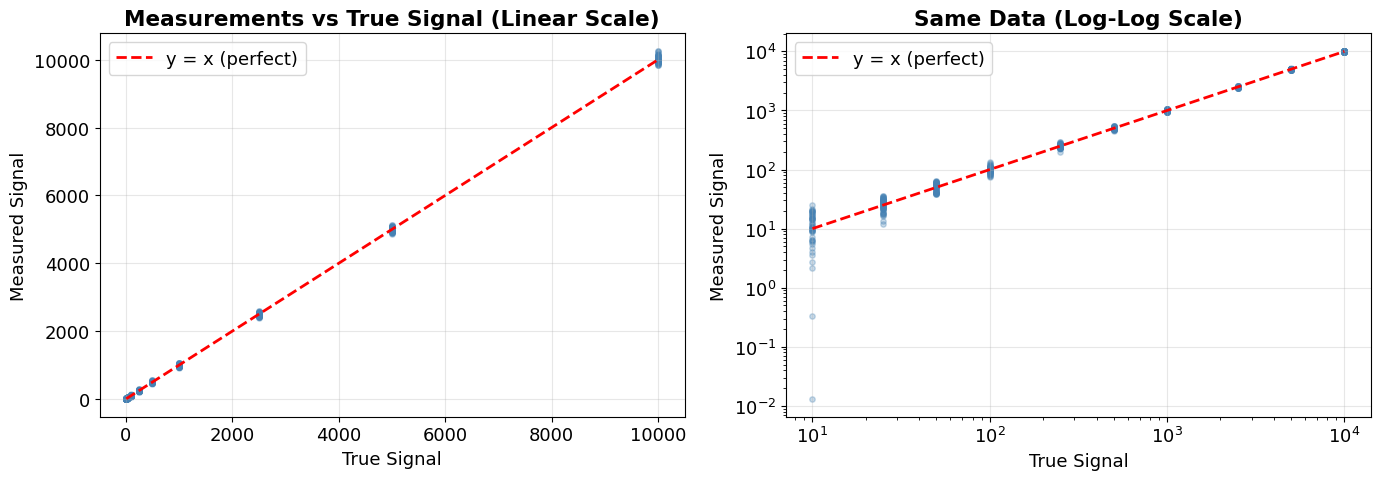

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Linear scale
for sig in true_signals:
    subset = df[df['true_signal'] == sig]
    ax1.scatter(np.full(len(subset), sig), subset['measurement'], 
                alpha=0.3, s=15, color='steelblue')
ax1.plot(true_signals, true_signals, 'r--', linewidth=2, label='y = x (perfect)')
ax1.set_xlabel('True Signal')
ax1.set_ylabel('Measured Signal')
ax1.set_title('Measurements vs True Signal (Linear Scale)', fontweight='bold')
ax1.legend()

# Log scale — does the scatter look constant here?
for sig in true_signals:
    subset = df[df['true_signal'] == sig]
    ax2.scatter(np.full(len(subset), sig), subset['measurement'], 
                alpha=0.3, s=15, color='steelblue')
ax2.plot(true_signals, true_signals, 'r--', linewidth=2, label='y = x (perfect)')
ax2.set_xlabel('True Signal')
ax2.set_ylabel('Measured Signal')
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_title('Same Data (Log-Log Scale)', fontweight='bold')
ax2.legend()

plt.tight_layout()
plt.show()

## Part 3: Measure the Noise at Each Signal Level

**Exercise 2:** For each signal level, calculate the standard deviation of the replicate measurements. Then plot SD vs signal level.

**Question to consider:** If noise were purely homoscedastic, what would this plot look like? What about purely heteroscedastic?

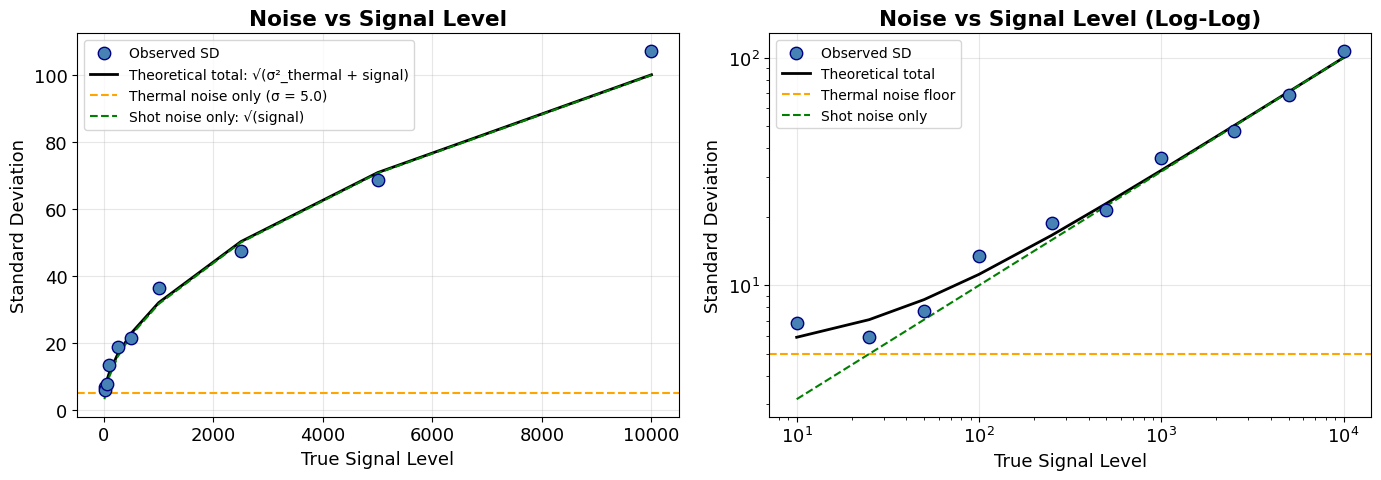

At low signals: thermal (homoscedastic) noise dominates → flat region
At high signals: shot (heteroscedastic) noise dominates → SD grows with √signal

Crossover point: when signal ≈ σ²_thermal = 25


In [4]:
# Calculate observed SD at each signal level
summary = df.groupby('true_signal')['measurement'].agg(['mean', 'std', 'count']).reset_index()
summary.columns = ['true_signal', 'mean_measured', 'observed_sd', 'n']

# Also compute the theoretical components
summary['theoretical_thermal'] = sigma_thermal
summary['theoretical_shot'] = np.sqrt(summary['true_signal'])
summary['theoretical_total'] = np.sqrt(sigma_thermal**2 + summary['true_signal'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# SD vs signal (linear)
ax1.scatter(summary['true_signal'], summary['observed_sd'], s=80, zorder=5, 
            color='steelblue', edgecolors='navy', label='Observed SD')
ax1.plot(summary['true_signal'], summary['theoretical_total'], 'k-', linewidth=2, 
         label='Theoretical total: √(σ²_thermal + signal)')
ax1.axhline(y=sigma_thermal, color='orange', linestyle='--', linewidth=1.5, 
            label=f'Thermal noise only (σ = {sigma_thermal})')
ax1.plot(summary['true_signal'], summary['theoretical_shot'], 'g--', linewidth=1.5, 
         label='Shot noise only: √(signal)')
ax1.set_xlabel('True Signal Level')
ax1.set_ylabel('Standard Deviation')
ax1.set_title('Noise vs Signal Level', fontweight='bold')
ax1.legend(fontsize=10)

# SD vs signal (log-log)
ax2.scatter(summary['true_signal'], summary['observed_sd'], s=80, zorder=5, 
            color='steelblue', edgecolors='navy', label='Observed SD')
ax2.plot(summary['true_signal'], summary['theoretical_total'], 'k-', linewidth=2, 
         label='Theoretical total')
ax2.axhline(y=sigma_thermal, color='orange', linestyle='--', linewidth=1.5, 
            label=f'Thermal noise floor')
ax2.plot(summary['true_signal'], summary['theoretical_shot'], 'g--', linewidth=1.5, 
         label='Shot noise only')
ax2.set_xlabel('True Signal Level')
ax2.set_ylabel('Standard Deviation')
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_title('Noise vs Signal Level (Log-Log)', fontweight='bold')
ax2.legend(fontsize=10)

plt.tight_layout()
plt.show()

print("At low signals: thermal (homoscedastic) noise dominates → flat region")
print("At high signals: shot (heteroscedastic) noise dominates → SD grows with √signal")
print(f"\nCrossover point: when signal ≈ σ²_thermal = {sigma_thermal**2:.0f}")

## Part 4: Residual Plots — The Diagnostic Tool

A **residual plot** shows (measured - true) vs the true value. This is one of the best ways to diagnose whether your measurement error is homoscedastic or heteroscedastic.

**Exercise 3:** Examine the residual plots below. Sketch (on paper) what you'd expect to see for:
1. Purely homoscedastic noise
2. Purely heteroscedastic noise
3. A mixture of both

Then check your intuition against the simulated data.

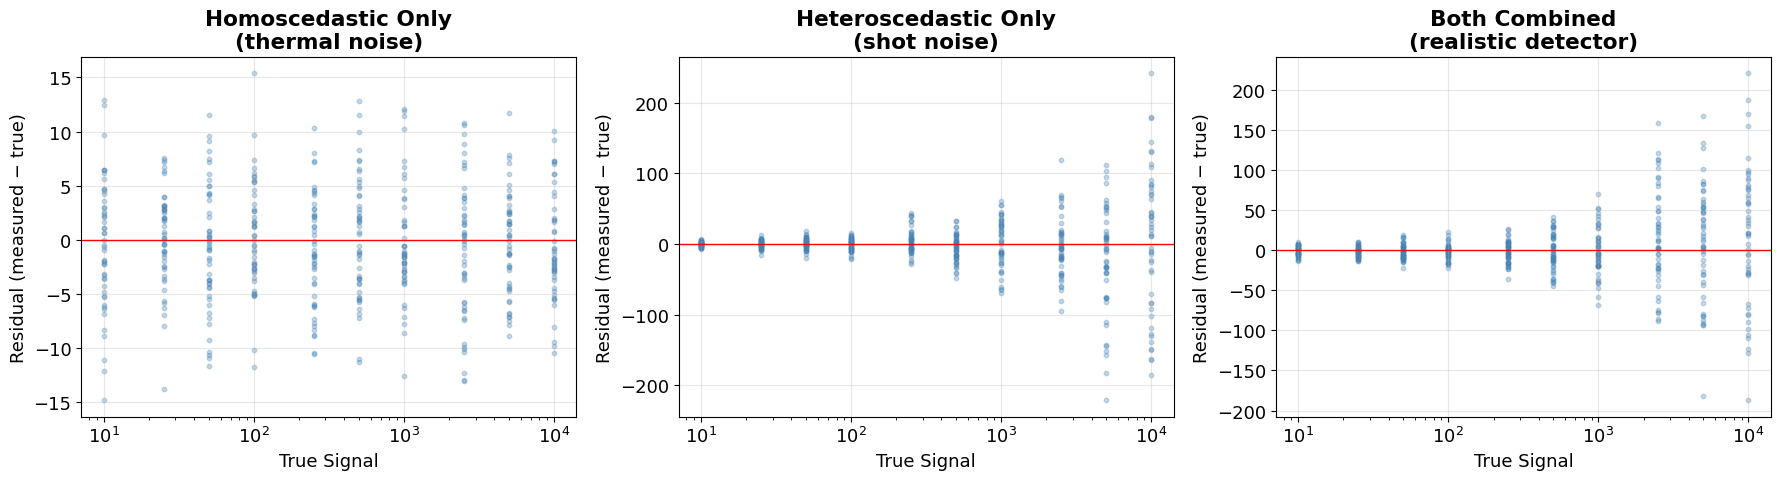

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

scenarios = [
    ("Homoscedastic Only\n(thermal noise)", lambda s: sigma_thermal),
    ("Heteroscedastic Only\n(shot noise)", lambda s: np.sqrt(s)),
    ("Both Combined\n(realistic detector)", lambda s: np.sqrt(sigma_thermal**2 + s)),
]

for ax, (title, noise_func) in zip(axes, scenarios):
    residuals = []
    signals = []
    for sig in true_signals:
        sigma = noise_func(sig)
        meas = np.random.normal(sig, sigma, n_replicates)
        residuals.extend(meas - sig)
        signals.extend([sig] * n_replicates)
    
    ax.scatter(signals, residuals, alpha=0.3, s=10, color='steelblue')
    ax.axhline(y=0, color='red', linestyle='-', linewidth=1)
    ax.set_xlabel('True Signal')
    ax.set_ylabel('Residual (measured − true)')
    ax.set_title(title, fontweight='bold')
    ax.set_xscale('log')

plt.tight_layout()
plt.show()

## Part 5: Coefficient of Variation (CV)

The **coefficient of variation** (CV = SD / mean) is another way to see the noise structure. 

**Exercise 4:** Before running the next cell, predict: for shot noise alone, how should CV change with signal level? (Hint: if SD = √signal, what is SD/signal?)

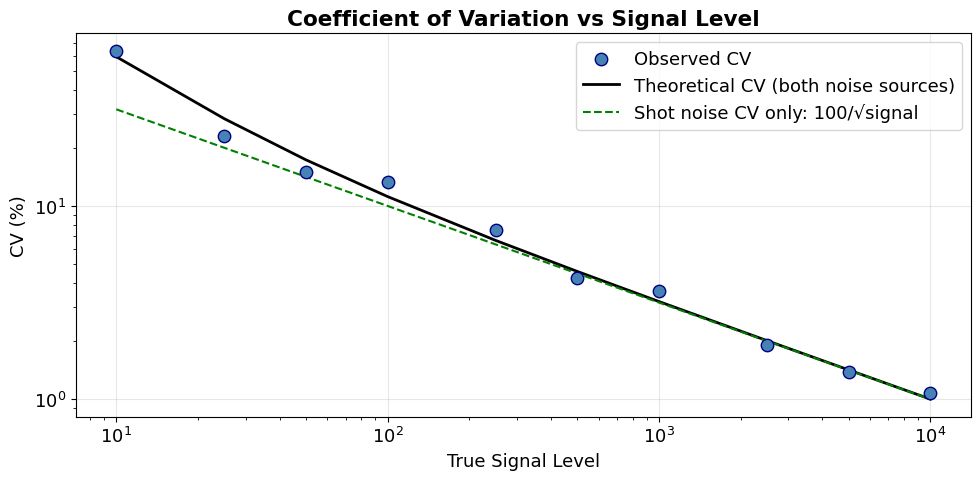

CV decreases with increasing signal — this is why we want MORE signal!
At high signals, CV approaches the shot noise limit: 100/√N
At low signals, thermal noise dominates and CV becomes very large


In [6]:
summary['cv_observed'] = summary['observed_sd'] / summary['mean_measured'] * 100  # as percent
summary['cv_shot_only'] = 100 / np.sqrt(summary['true_signal'])  # theoretical: 1/√N * 100%
summary['cv_total_theoretical'] = summary['theoretical_total'] / summary['true_signal'] * 100

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(summary['true_signal'], summary['cv_observed'], s=80, zorder=5,
           color='steelblue', edgecolors='navy', label='Observed CV')
ax.plot(summary['true_signal'], summary['cv_total_theoretical'], 'k-', linewidth=2,
        label='Theoretical CV (both noise sources)')
ax.plot(summary['true_signal'], summary['cv_shot_only'], 'g--', linewidth=1.5,
        label='Shot noise CV only: 100/√signal')
ax.set_xlabel('True Signal Level')
ax.set_ylabel('CV (%)')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_title('Coefficient of Variation vs Signal Level', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print("CV decreases with increasing signal — this is why we want MORE signal!")
print("At high signals, CV approaches the shot noise limit: 100/√N")
print("At low signals, thermal noise dominates and CV becomes very large")

## Part 6: Your Turn — Modify the Parameters

Go back to the data generation cell (Part 1) and try changing:

1. **`sigma_thermal = 20`** — What happens when thermal noise is much larger? Where does the crossover move?
2. **`sigma_thermal = 0.5`** — What if thermal noise is negligible? 
3. **Add more replicates** (`n_replicates = 200`) — Does the observed SD converge closer to theory?

**Key takeaways:**
- Homoscedastic noise sets a **floor** on measurement precision — it limits detection at low signals
- Heteroscedastic noise grows with signal but the **relative precision** (CV) actually improves
- The crossover point (signal ≈ σ²_thermal) determines which noise source dominates your experiment
- This directly affects how you should weight data in quantitative analysis and where you set detection limits